In [121]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [122]:
# get the csvs to df
train_txn = pd.read_csv('rawdata/train_transaction.csv')
train_id = pd.read_csv('rawdata/train_identity.csv')
train_combined = train_txn.merge(train_id, on='TransactionID', how='left')

test_txn = pd.read_csv('rawdata/test_transaction.csv')
test_id = pd.read_csv('rawdata/test_identity.csv')
test_combined = test_txn.merge(test_id, on='TransactionID', how='left')


# ▸ EDA

In [124]:
print('Train:')
print(train_combined.shape)
print('--------------------------------')
print(train_combined.dtypes)
print('--------------------------------')
print(train_combined.dtypes.value_counts())
print('--------------------------------')
print(train_combined.memory_usage(deep=True).sum() / 1e9, "GB")

Train:
(590540, 434)
--------------------------------
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object
--------------------------------
float64    399
str         31
int64        4
Name: count, dtype: int64
--------------------------------
2.636093316 GB


In [125]:
print('Test:')
print(test_combined.shape)
print('--------------------------------')
print(test_combined.dtypes)
print('--------------------------------')
print(test_combined.dtypes.value_counts())
print('--------------------------------')
print(test_combined.memory_usage(deep=True).sum() / 1e9, "GB")

Test:
(506691, 433)
--------------------------------
TransactionID       int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
                   ...   
id-36                 str
id-37                 str
id-38                 str
DeviceType            str
DeviceInfo            str
Length: 433, dtype: object
--------------------------------
float64    399
str         31
int64        3
Name: count, dtype: int64
--------------------------------
2.269222644 GB


In [126]:
train_combined.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [127]:
train_combined.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [128]:
test_combined.head(5)

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
test_combined.describe()

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,id-17,id-18,id-19,id-20,id-21,id-22,id-24,id-25,id-26,id-32
count,5.066910e+05,5.066910e+05,506691.000000,506691.000000,498037.000000,503689.000000,502144.000000,441082.000000,441082.000000,215474.000000,...,135966.000000,50875.000000,135906.000000,135633.000000,5059.000000,5062.000000,4740.000000,5039.000000,5047.000000,70671.000000
mean,3.916894e+06,2.692994e+07,134.725568,9957.222175,363.735379,153.543409,200.162975,291.846514,86.723412,87.065270,...,191.070341,14.795735,350.122982,408.886230,507.727021,15.336823,13.166667,332.043064,152.752923,26.217939
std,1.462692e+05,4.756507e+06,245.779822,4884.960969,158.688653,12.443013,40.562461,102.062730,2.987328,314.131694,...,30.749535,2.318496,139.140824,158.971756,227.371061,5.618032,3.222440,86.356683,31.916995,3.601046
min,3.663549e+06,1.840322e+07,0.018000,1001.000000,100.000000,100.000000,100.000000,100.000000,10.000000,0.000000,...,100.000000,11.000000,100.000000,100.000000,100.000000,11.000000,10.000000,100.000000,100.000000,8.000000
25%,3.790222e+06,2.277154e+07,40.000000,6019.000000,207.000000,150.000000,166.000000,204.000000,87.000000,3.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,137.000000,24.000000
50%,3.916894e+06,2.720466e+07,67.950000,9803.000000,369.000000,150.000000,226.000000,299.000000,87.000000,8.000000,...,166.000000,15.000000,321.000000,484.000000,576.000000,14.000000,11.000000,321.000000,147.000000,24.000000
75%,4.043566e+06,3.134856e+07,125.000000,14276.000000,512.000000,150.000000,226.000000,330.000000,87.000000,20.000000,...,225.000000,15.000000,427.000000,549.000000,711.000000,14.000000,15.000000,355.000000,182.000000,32.000000
max,4.170239e+06,3.421434e+07,10270.000000,18397.000000,600.000000,232.000000,237.000000,540.000000,102.000000,8081.000000,...,228.000000,29.000000,670.000000,660.000000,854.000000,44.000000,26.000000,549.000000,216.000000,48.000000


In [130]:
train_combined['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

<class 'pandas.Series'>
434


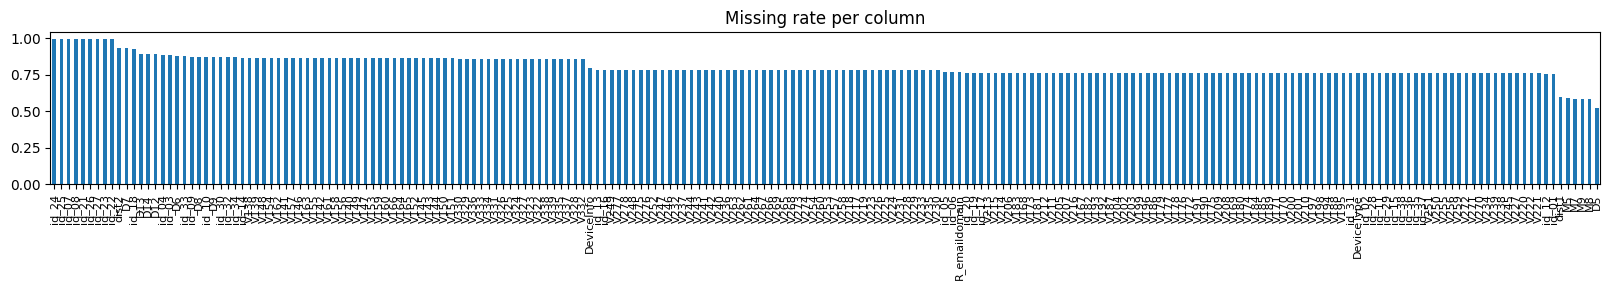

In [131]:
# any cells with missing value
missing = train_combined.isnull().mean().sort_values(ascending=False)
print(type(missing))
print(missing.size) # pandas Series object has no len(s) function
ax = missing[missing > 0.5].plot(kind='bar', figsize=(20,4), title='Missing rate per column')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.subplots_adjust(bottom=0.5)
#plt.tight_layout()
plt.show()
# there are lots of missing values
# any features that has more than half of its entry missing => discard them?

In [132]:
print(train_combined.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

C:\Users\minim\AppData\Local\Temp\ipykernel_28964\3054835351.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_combined['TransactionDay'] = train_combined['TransactionDT'] // 86400 # 86400 seconds per day


182


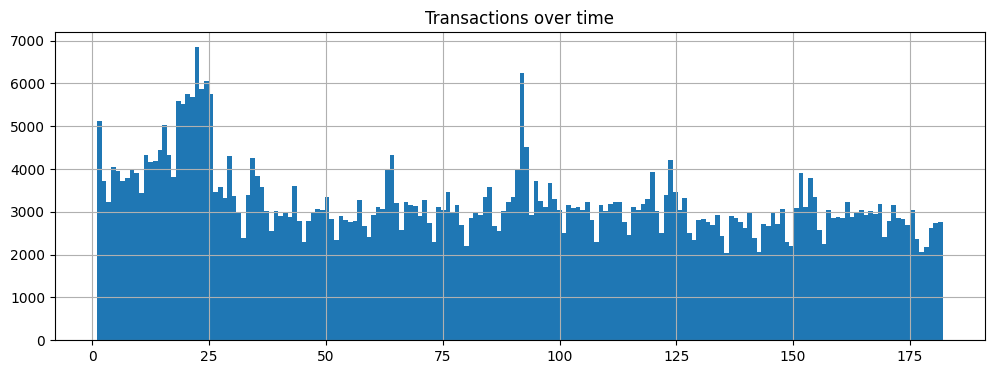

In [133]:
# time distribution
train_combined['TransactionDay'] = train_combined['TransactionDT'] // 86400 # 86400 seconds per day
train_combined['TransactionDay'].hist(bins=182, figsize=(12,4))
train_combined = train_combined.copy()
plt.title('Transactions over time')
# counts how many days are there in the train dataset / how long is the dataset collected
print(train_combined['TransactionDay'].nunique())

Text(0.5, 1.0, 'Fraud rate over time')

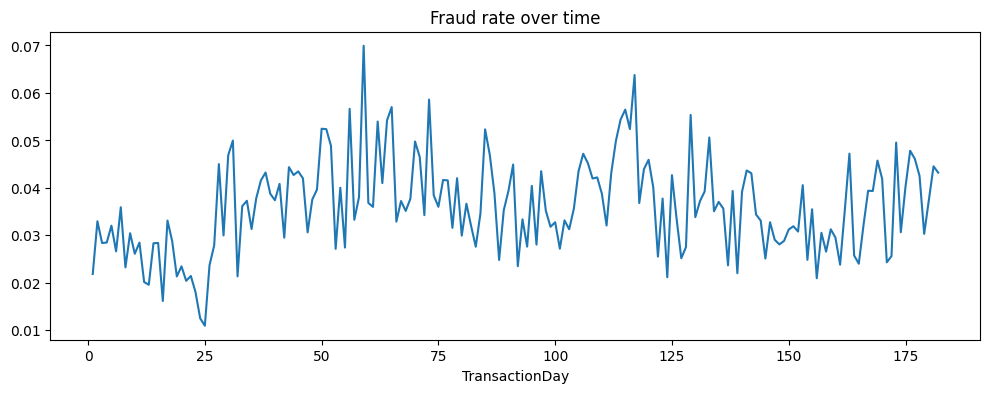

In [134]:
# fraud rate over time
train_combined.groupby('TransactionDay')['isFraud'].mean().plot(figsize=(12,4))
plt.title('Fraud rate over time')

<Axes: >

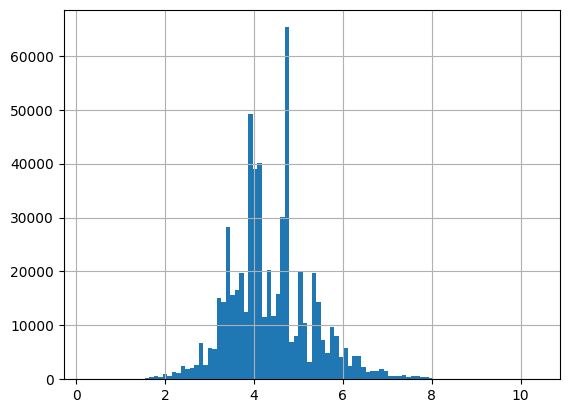

In [135]:
# transaction amount distribution
np.log1p(train_combined['TransactionAmt']).hist(bins=100)

In [136]:
# card column families
for col in ['card1','card2','card3','card4','card5','card6']:
    print(col, train_combined[col].nunique(), 'unique values')

card1 13553 unique values
card2 500 unique values
card3 114 unique values
card4 4 unique values
card5 119 unique values
card6 4 unique values


In [137]:
# looking for missing data,
# outliers/range sanity
# scale differences
# skew hints
train_combined[['D1','D2','D3','D4','D10','D15']].describe()

,D1,D2,D3,D4,D10,D15
count,589271.000000,309743.000000,327662.000000,421618.000000,514518.000000,501427.000000
mean,94.347568,169.563231,28.343348,140.002441,123.982137,163.744579
std,157.660387,177.315865,62.384721,191.096774,182.615225,202.726660
min,0.000000,0.000000,0.000000,-122.000000,0.000000,-83.000000
25%,0.000000,26.000000,1.000000,0.000000,0.000000,0.000000
50%,3.000000,97.000000,8.000000,26.000000,15.000000,52.000000
75%,122.000000,276.000000,27.000000,253.000000,197.000000,314.000000
max,640.000000,640.000000,819.000000,869.000000,876.000000,879.000000


# ▸ time-series leakage experiment

In [143]:
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    f1_score, classification_report, confusion_matrix, precision_recall_curve
)
import seaborn as sns
from sklearn.model_selection import train_test_split

In [144]:
# config
TARGET = "isFraud"
TIME_COL = "TransactionDT" # Unix-delta seconds
TEST_SIZE = 0.2
RANDOM_STATE = 42

# base LightGBM params (no imbalance handling)
BASE_PARAMS = dict(
    objective = "binary",
    metric = "auc",
    learning_rate = 0.05,
    num_leaves = 63,
    min_child_samples = 20,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq = 1,
    verbose = -1,
    n_estimators = 500,
    random_state = RANDOM_STATE,
    categorical_feature="auto"
)

In [145]:
# data loading
def load_data(train_identity_path: str, train_transaction_path: str) -> pd.DataFrame:
    # merge transaction and identity table
    transactions = pd.read_csv(train_transaction_path)
    identities = pd.read_csv(train_identity_path)
    df = transactions.merge(identities, on="TransactionID", how="left")
    return df

In [146]:
### split comparison ###
# random split train_test
def random_split(df: pd.DataFrame):
    # standard random stratified split 
    features = [c for c in df.columns if c not in [TARGET, "TransactionID", TIME_COL]]
    X = df[features]
    y = df[TARGET]
    return train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

# time split (older transactions vs newer transactions)
def time_split(df: pd.DataFrame):
    # first (1-TEST_SIZE) of time -> train
    # last (TEST_SIZE) of time -> test
    df_sorted = df.sort_values(TIME_COL).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1-TEST_SIZE)) # what is the data type of all these elements
    features = [c for c in df.columns if c not in [TARGET, "TransactionID", TIME_COL]]

    X_train = df_sorted.iloc[:split_idx][features]
    X_test = df_sorted.iloc[split_idx:][features]
    y_train = df_sorted.iloc[:split_idx][TARGET]
    y_test = df_sorted.iloc[split_idx:][TARGET]
    return X_train, X_test, y_train, y_test

In [147]:
### LGBM's baseline vs scale_pos_weight vs is_unbalance comparison ###
def get_model_configs(neg: int, pos: int) -> dict:
    # return 3 LGBM conifgs:
    # baseline -> no imbalance handling
    # scale_pos_weight -> weight the positive class
    # is_unbalance -> LGBM resampling flag
    spw = neg / pos
    variants = {
        "baseline": lgb.LGBMClassifier(**BASE_PARAMS),
        "scale_pos_weight": lgb.LGBMClassifier(scale_pos_weight=spw,**BASE_PARAMS),
        "is_unbalance": lgb.LGBMClassifier(
            **{k: v for k, v in BASE_PARAMS.items()
               if k != "scale_pos_weight"},   # remove scale_pos_weight from the params list
            is_unbalance=True
        )
    }
    return variants

In [148]:
### train & evaluate ###
def train_and_evaluate(X_train, X_test, y_train, y_test, model_name: str, model) -> dict:
    # fit model
    # return dict of metrics & prediction arrays
    callbacks = [lgb.early_stopping(50, verbose=False),
                 lgb.log_evaluation(period=-1)]
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=callbacks
    )

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    recall_fraud = tp / (tp + fn) if (tp + fn) else 0
    precision_fraud = tp / (tp + fp) if (tp + fp) else 0

    return {
        "model_name": model_name,
        "auc_roc": round(auc, 4),
        "avg_precision": round(ap, 4),
        "f1": round(f1, 4),
        "recall_fraud": round(recall_fraud, 4),
        "precision_fraud": round(precision_fraud, 4),
        "confusion_matrix": cm,
        "y_prob": y_prob,
        "y_test": y_test,
        "best_iteration": model.best_iteration_
    }

In [149]:
# run the experiment!
def run_split_experiment(df: pd.DataFrame, split_name: str, split_fn) -> list[dict]:
    # run all three model variants on two split strategies
    X_train, X_test, y_train, y_test = split_fn(df)

    neg = int((y_train == 0).sum())
    pos = int((y_train == 1).sum())
    print(f"\n{'='*60}")
    print(f" Split: {split_name}")
    print(f"   Train -> legit: {neg:,} fraud: {pos:,}   "
          f"({pos/(neg+pos)*100:.2f}% fraud)")

    if pos == 0:
        print(" ! no fraud cases in training set - skip this split")
        return []

    neg_t = int((y_test == 0).sum())
    pos_t = int((y_test == 1).sum())
    print(f"   Test -> legit: {neg_t:,} fraud: {pos_t:,}   "
          f"({pos_t/(neg_t+pos_t)*100:.2f}% fraud)")
    print(f"{'='*60}")

    variants = get_model_configs(neg, pos)
    result = []

    for vname, model in variants.items():
        print(f"   Training [{vname}] ...", end=" ", flush=True)
        res = train_and_evaluate(X_train, X_test, y_train, y_test, vname, model)
        res["split"] = split_name
        result.append(res)
        print(f"AUC={res['auc_roc']} AP={res['avg_precision']}   "
              f"F1={res['f1']}")
    
    return result

In [150]:
# plotting
import matplotlib.gridspec as gridspec

COLORS = {"baseline": "#4e79a7",
          "scale_pos_weight": "#f28e2b",
          "is_unbalance": "#59a14f"}
SPLITS = ["Random Split", "Time-based Split"]

def plot_results(all_results: list[dict], save_path: str = "lgbm_results.png"):
    fig = plt.figure(figsize=(20, 22))
    fig.suptitle("LightGBM Fraud Detection - Experiment Results", fontsize=16, fontweight="bold", y= 0.98)

    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

    # metric bar charts (AUC, AP, F1, Recall)
    # is it needed?
    metrics = [
        ("auc_roc",         "AUC-ROC",              gs[0, 0]),
        ("avg_precision",   "Avg Precision (AP)",   gs[0, 1]),
        ("f1",              "F1 Score",             gs[1, 0]),
        ("recall_fraud",    "Recall (Fraud)",       gs[1, 1])
    ]

    for metric_key, metric_label, gsp in metrics:
        ax = fig.add_subplot(gsp)
        x = np.arange(len(SPLITS))
        w = 0.25
        for i, vname in enumerate(["baseline", "scale_pos_weight", "is_unbalance"]):
            vals = [r[metric_key] for r in all_results if r["model_name"] == vname]
            bars = ax.bar(x + (i-1)*w, vals, w, label=vname, color=COLORS[vname], alpha=0.85)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.002,
                        f"{val:.4f}", ha="center", va="bottom",
                        fontsize=7.5, rotation=0)
        ax.set_title(metric_label, fontsize=22, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(SPLITS, fontsize=9)
        ax.set_ylim(0, min(1.0, ax.get_ylim()[1] * 1.12))
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    # ROC curves
    for col, split_name in enumerate(SPLITS):
        ax = fig.add_subplot(gs[2, col])
        split_results = [r for r in all_results if r["split"] == split_name]
        for res in split_results:
            fpr, tpr, _ = roc_curve(res["y_test"], res["y_prob"])
            ax.plot(fpr, tpr, label=f"{res['model_name']} (AUC={res['auc_roc']})",
                    color=COLORS[res["model_name"]], lw=1.8)
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
        ax.set_title(f"ROC Curve - {split_name}", fontsize=10, fontweight="bold")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(fontsize=8); ax.grid(alpha=0.3) # ; here is to suppress the output of the last command of this cell

    # Precision-Recall Curve
    for col, split_name in enumerate(SPLITS):
        ax = fig.add_subplot(gs[3, col])
        split_results = [r for r in all_results if r["split"] == split_name]
        for res in split_results:
            prec, rec, _ = precision_recall_curve(res["y_test"], res["y_prob"])
            ax.plot(rec, prec,
                    label=f"{res['model_name']} (ap={res['avg_precision']})",
                    color=COLORS[res["model_name"]], lw=1.8)
        ax.set_title(f"Precision-Recall - {split_name}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\n Plot saved -> {save_path}")

# summary table
def print_summary_table(all_results: list[dict]):
    rows = []
    for r in all_results:
        rows.append({
            "Split"             : r["split"],
            "Model"             : r["model_name"],
            "AUC-ROC"           : r["auc_roc"],
            "Avg Precision"     : r["avg_precision"],
            "F1"                : r["f1"],
            "Recall (Fraud)"    : r["recall_fraud"],
            "Precision (Fraud)" : r["precision_fraud"],
            "Best Iteration"    : r["best_iteration"]
        })
    df = pd.DataFrame(rows).sort_values(["Split", "AUC-ROC"], ascending=[True, False])
    print("\n\n-- SUMMARY TABLE ------------------------------")
    print(df.to_string(index=False))
    return df


 Split: Random Split
   Train -> legit: 455,902 fraud: 16,530   (3.50% fraud)
   Test -> legit: 113,975 fraud: 4,133   (3.50% fraud)
   Training [baseline] ... 

c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warni

AUC=0.9626 AP=0.8064   F1=0.716
   Training [scale_pos_weight] ... 

c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warni

AUC=0.9633 AP=0.7758   F1=0.5293
   Training [is_unbalance] ... 

...

AUC=0.9154 AP=0.5713   F1=0.4989
   Training [scale_pos_weight] ... 

c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warni

AUC=0.9108 AP=0.5309   F1=0.3771
   Training [is_unbalance] ... 

c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\minim\MLcoursework\transactionfraudprediction\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warni

AUC=0.9108 AP=0.5309   F1=0.3771


-- SUMMARY TABLE ------------------------------
           Split            Model  AUC-ROC  Avg Precision     F1  Recall (Fraud)  Precision (Fraud)  Best Iteration
    Random Split scale_pos_weight   0.9633         0.7758 0.5293          0.8459             0.3852             500
    Random Split     is_unbalance   0.9633         0.7758 0.5293          0.8459             0.3852             500
    Random Split         baseline   0.9626         0.8064 0.7160          0.5746             0.9496             500
Time-based Split         baseline   0.9154         0.5713 0.4989          0.3575             0.8251             360
Time-based Split scale_pos_weight   0.9108         0.5309 0.3771          0.7210             0.2554             213
Time-based Split     is_unbalance   0.9108         0.5309 0.3771          0.7210             0.2554             213

 Plot saved -> ./graphs

Done


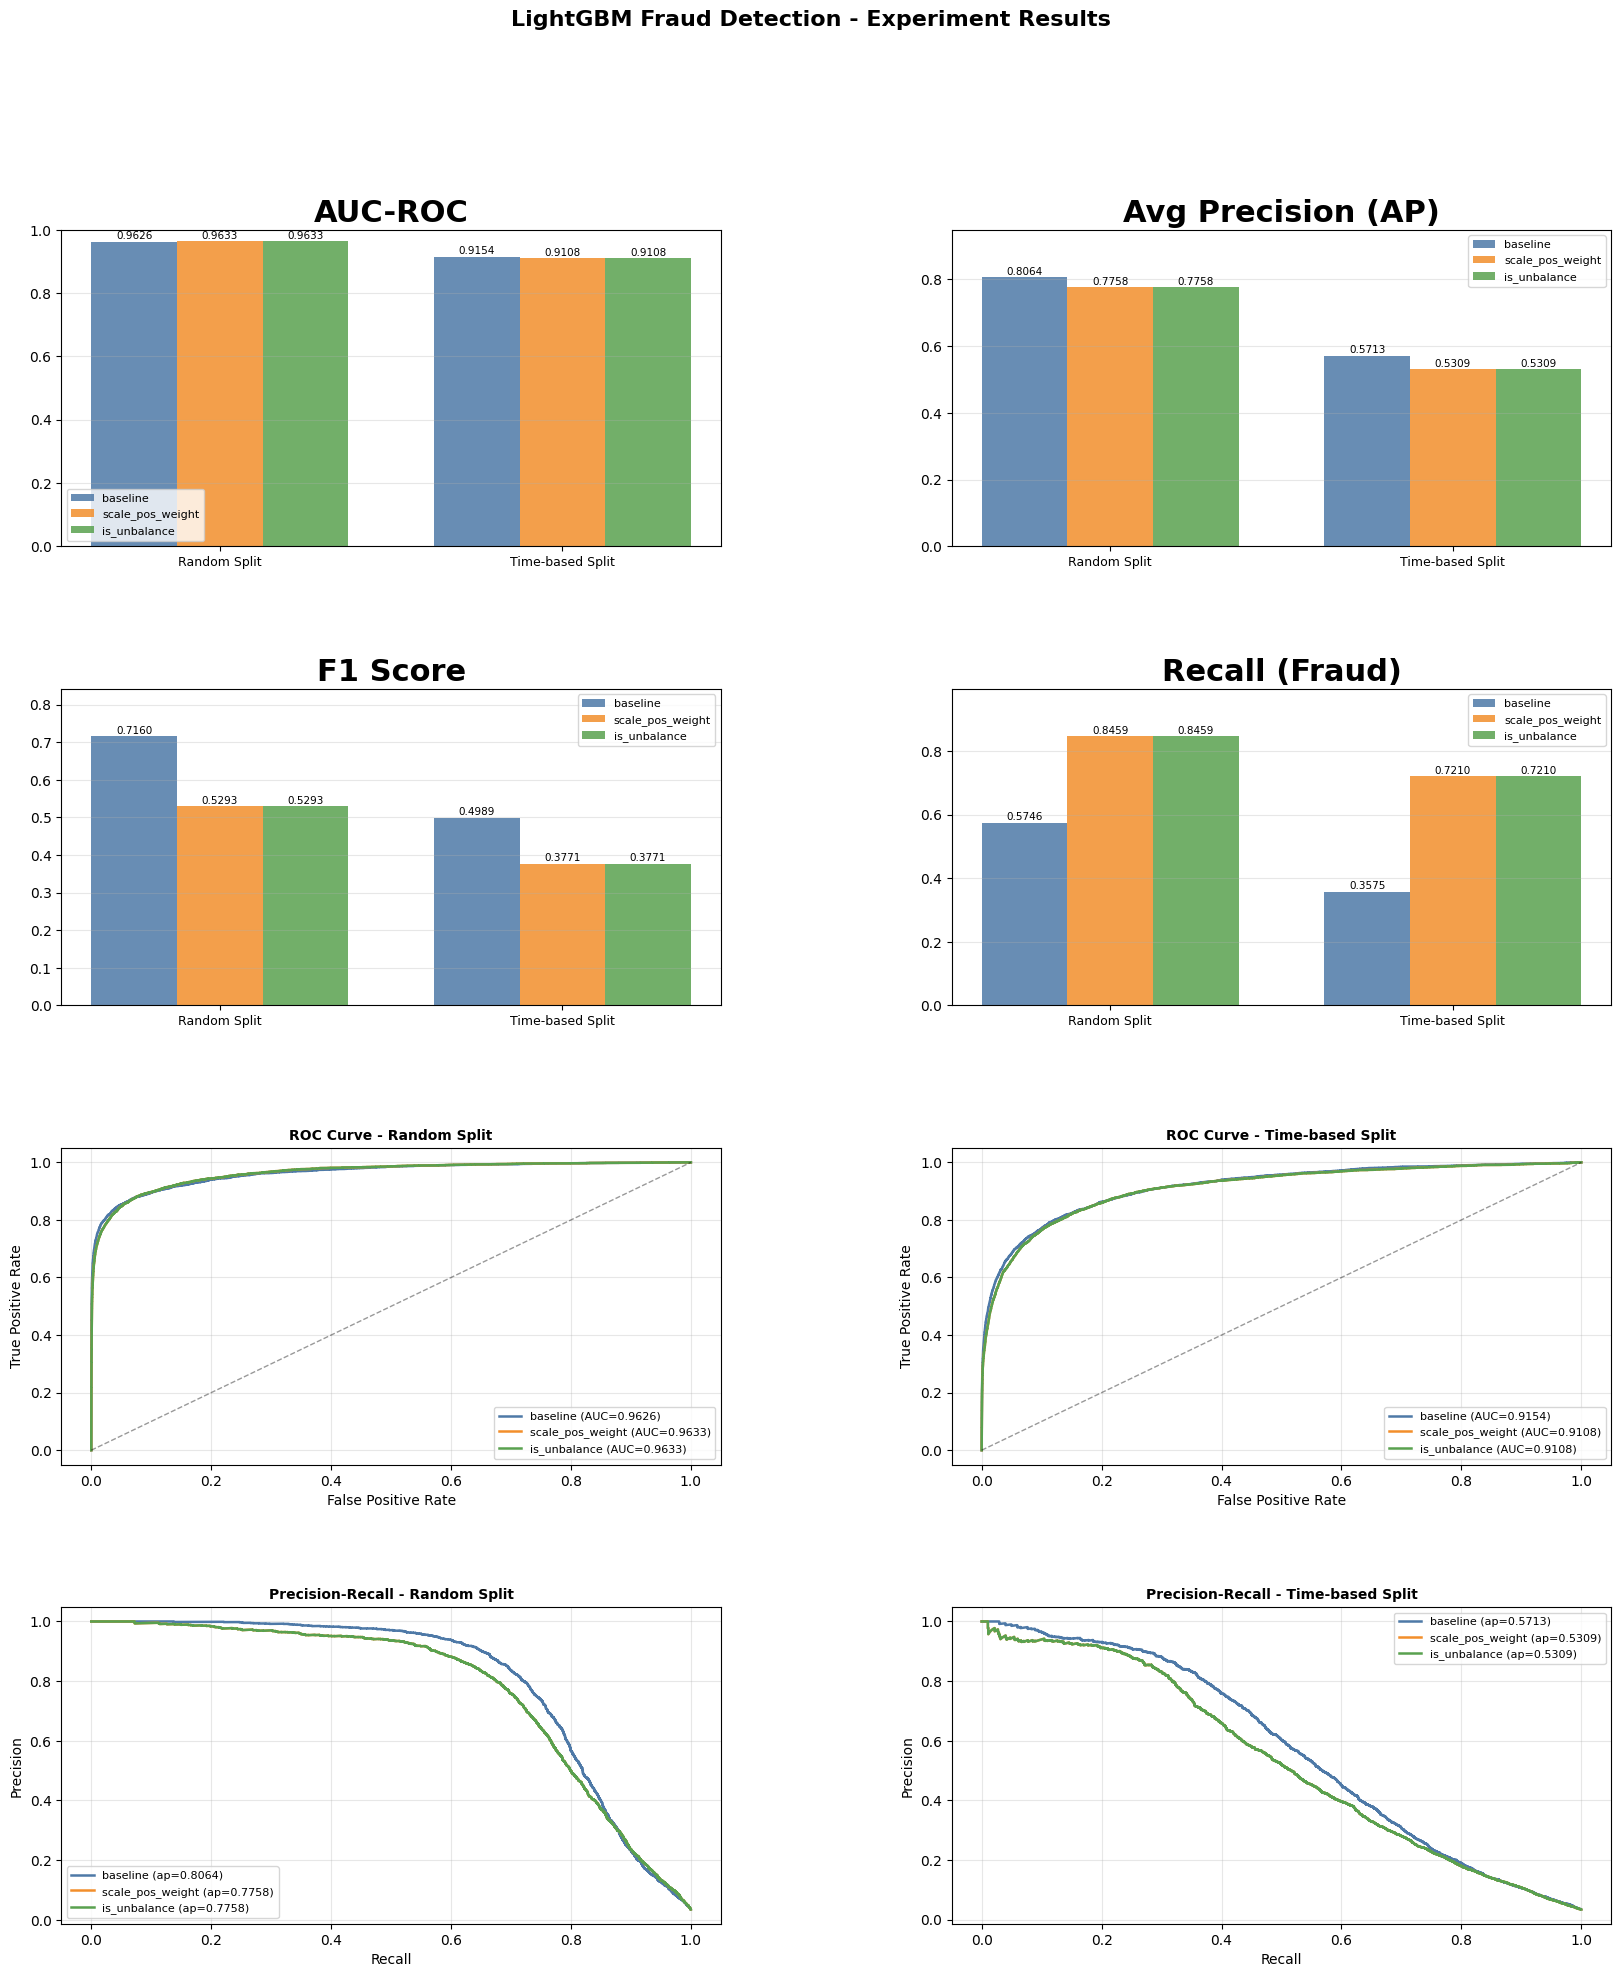

In [151]:
# Main - running the whole thing
if __name__ == "__main__":
    # load data
    df = load_data("rawdata/train_identity.csv","rawdata/train_transaction.csv")

    # for columns with string and object datatype -> convert to category
    string_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in string_cols:
        df[col] = df[col].astype('category')

    # run experiment
    all_results = []
    all_results += run_split_experiment(df, "Random Split", lambda d: random_split(d))
    all_results += run_split_experiment(df, "Time-based Split", lambda d: time_split(d))
    # summary
    summary_df = print_summary_table(all_results)
    # plot
    plot_results(all_results, save_path="./graphs")

    print("\nDone")